In [88]:
#Installing libraries
!pip install yfinance pandas numpy scikit-learn xgboost lightgbm ta



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [89]:
!pip install matplotlib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [90]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# 2 years back from today
end_date = datetime.today()
start_date = end_date - timedelta(days=5*365)

# Primary stock + crypto 
# Using HUT.TO (TSX, CAD) instead of HUT (NASDAQ, USD)
ticker_stock = "HUT.TO"
ticker_crypto = "BTC-USD"

hut = yf.download(ticker_stock, start=start_date, end=end_date)
btc = yf.download(ticker_crypto, start=start_date, end=end_date)

print("HUT.TO data shape:", hut.shape)
print("BTC data shape:", btc.shape)

hut.head(), btc.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

HUT.TO data shape: (1253, 5)
BTC data shape: (1826, 5)


(Price           Close       High        Low       Open  Volume
 Ticker         HUT.TO     HUT.TO     HUT.TO     HUT.TO  HUT.TO
 Date                                                          
 2021-04-15  39.950001  41.650002  38.099998  41.000000  280500
 2021-04-16  37.400002  39.349998  37.349998  39.049999  241640
 2021-04-19  33.849998  36.500000  30.700001  35.000000  556000
 2021-04-20  35.500000  38.349998  33.500000  34.349998  346380
 2021-04-21  35.150002  35.700001  33.549999  34.400002  202280,
 Price              Close          High           Low          Open  \
 Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
 Date                                                                 
 2021-04-14  63109.695312  64863.097656  61554.796875  63523.753906   
 2021-04-15  63314.011719  63821.671875  62208.964844  63075.195312   
 2021-04-16  61572.789062  63594.722656  60222.531250  63258.503906   
 2021-04-17  60683.820312  62572.175781  60361.351562  61529.

# Align & Merge HUT + BTC Data


**HUT8 and Bitcoin trade on different schedules:**

-Stocks → no weekends

-Crypto → trades 24/7

This means their datasets have different dates, which will break our ML model unless we align them.

**So in this step, we:**

-Convert both datasets to daily frequency

-Forward‑fill missing days (weekends/holidays)

-Rename BTC columns to avoid confusion

-Merge both datasets into one clean DataFrame

-This gives us a single, synchronized dataset ready for feature engineering.

**This merged dataset becomes the foundation for:**

-Feature engineering

-Hybrid technical indicators

-Crypto correlation features

-Model building and ML model training

In [91]:
# Convert both datasets to daily frequency
hut = hut.asfreq('D')         #Used asfreq('D') is used to force the data to have a daily frequency, which is important for time series analysis and modeling. 
btc = btc.asfreq('D')         #This ensures that both datasets have the same time index, making it easier to merge and analyze them together.

# Forward-fill missing values (weekends, holidays)
hut = hut.ffill()
btc = btc.ffill()

# Rename BTC columns to avoid confusion
btc = btc.add_prefix("BTC_")

# Merge on date index
df = hut.join(btc, how='inner')

print("Merged Data Shape:", df.shape)
df.head()


Merged Data Shape: (1825, 10)


Price,Close,High,Low,Open,Volume,BTC_Close,BTC_High,BTC_Low,BTC_Open,BTC_Volume
Ticker,HUT.TO,HUT.TO,HUT.TO,HUT.TO,HUT.TO,BTC_BTC-USD,BTC_BTC-USD,BTC_BTC-USD,BTC_BTC-USD,BTC_BTC-USD
Date,,,,,,,,,,
2021-04-15,39.950001,41.650002,38.099998,41.000000,280500.0,63314.011719,63821.671875,62208.964844,63075.195312,60954381579
2021-04-16,37.400002,39.349998,37.349998,39.049999,241640.0,61572.789062,63594.722656,60222.531250,63258.503906,84293007468
2021-04-17,37.400002,39.349998,37.349998,39.049999,241640.0,60683.820312,62572.175781,60361.351562,61529.921875,66138759198
2021-04-18,37.400002,39.349998,37.349998,39.049999,241640.0,56216.183594,61057.457031,52829.535156,60701.886719,97468872758
2021-04-19,33.849998,36.500000,30.700001,35.000000,556000.0,55724.265625,57520.054688,54368.593750,56191.585938,65344865159


# Add Hybrid Features (Lag, Returns, MovingAverage, Volatility, RSI, MACD, BTC Features)


Machine learning models cannot understand raw price data alone.
They need features — numerical signals that help the model detect patterns.



In [92]:
'''I added this code to flatten the DataFrame and extract the real close column. Else I was getting error in
technical indicatior RSI calculation. Giving me error as my close clomn was 2 dimentional '''
#Flatten the DataFrame and extract the real Close column

# Flatten multi-index columns if they exist
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# Extract Close column properly
df['Close'] = df['Close'].astype(float)
df['Close'] = df['Close'].squeeze()
print(type(df['Close']))
print(df['Close'].shape)
df.head()

<class 'pandas.Series'>
(1825,)


,Close,High,Low,Open,Volume,BTC_Close,BTC_High,BTC_Low,BTC_Open,BTC_Volume
Date,,,,,,,,,,
2021-04-15,39.950001,41.650002,38.099998,41.000000,280500.0,63314.011719,63821.671875,62208.964844,63075.195312,60954381579
2021-04-16,37.400002,39.349998,37.349998,39.049999,241640.0,61572.789062,63594.722656,60222.531250,63258.503906,84293007468
2021-04-17,37.400002,39.349998,37.349998,39.049999,241640.0,60683.820312,62572.175781,60361.351562,61529.921875,66138759198
2021-04-18,37.400002,39.349998,37.349998,39.049999,241640.0,56216.183594,61057.457031,52829.535156,60701.886719,97468872758
2021-04-19,33.849998,36.500000,30.700001,35.000000,556000.0,55724.265625,57520.054688,54368.593750,56191.585938,65344865159


In [93]:
import numpy as np
import ta

# -----------------------------
# 1. PRICE-BASED FEATURES
# -----------------------------

# Lag features
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df['Close_Lag3'] = df['Close'].shift(3)

# Daily returns
df['Return_1D'] = df['Close'].pct_change()

# Moving averages
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# Rolling volatility
df['Volatility_5D'] = df['Close'].rolling(window=5).std()
df['Volatility_10D'] = df['Close'].rolling(window=10).std()


# -----------------------------
# SAFETY FIX — ensure Close is 1D float
# -----------------------------
df['Close'] = df['Close'].astype(float).squeeze()
df['BTC_Close'] = df['BTC_Close'].astype(float).squeeze()

# -----------------------------
# 2. TECHNICAL INDICATORS
# -----------------------------

# RSI
df['RSI'] = ta.momentum.RSIIndicator(
    close=df['Close'], 
    window=14
).rsi()

# MACD
macd = ta.trend.MACD(close=df['Close'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()



# -----------------------------
# 3. BTC FEATURES
# -----------------------------

# BTC returns
df['BTC_Return_1D'] = df['BTC_Close'].pct_change()

# BTC moving averages
df['BTC_MA5'] = df['BTC_Close'].rolling(window=5).mean()
df['BTC_MA10'] = df['BTC_Close'].rolling(window=10).mean()

# BTC volatility
df['BTC_Volatility_5D'] = df['BTC_Close'].rolling(window=5).std()


# -----------------------------
# FINAL CLEANUP
# -----------------------------

# Remove rows with NaN values created by rolling windows
df = df.dropna()

print("Final dataset shape after feature engineering:", df.shape)
df.head()


Final dataset shape after feature engineering: (1792, 26)


,Close,High,Low,Open,Volume,BTC_Close,BTC_High,BTC_Low,BTC_Open,BTC_Volume,...,MA20,Volatility_5D,Volatility_10D,RSI,MACD,MACD_Signal,BTC_Return_1D,BTC_MA5,BTC_MA10,BTC_Volatility_5D
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-18,25.00,25.700001,24.250000,24.950001,242040.0,42909.402344,45812.457031,42367.832031,43488.058594,56187365084,...,29.962501,1.602187,1.959280,31.676222,-2.515492,-2.279355,-0.014427,45908.739062,49920.710938,2802.607143
2021-05-19,24.15,24.299999,21.549999,21.799999,443580.0,37002.441406,43546.117188,30681.496094,42944.976562,126358098747,...,29.475000,1.797777,1.900556,30.037321,-2.639948,-2.351474,-0.137661,43333.120313,47797.723437,3930.532445
2021-05-20,24.90,26.400000,24.299999,25.200001,220980.0,40782.738281,42462.984375,35050.617188,36753.667969,88281943359,...,29.012500,1.466033,1.897667,33.315776,-2.647543,-2.410688,0.102163,42137.630469,46290.017578,3514.613078
2021-05-21,23.90,26.549999,23.650000,25.200001,305180.0,37304.691406,42172.171875,33616.453125,40596.949219,82051616861,...,28.500000,0.535023,2.006441,31.215409,-2.703093,-2.469169,-0.085282,40307.357031,44350.029297,3056.509226
2021-05-22,23.90,26.549999,23.650000,25.200001,305180.0,37536.632812,38831.054688,35383.683594,37371.031250,57377273240,...,27.987500,0.540370,1.686952,31.215409,-2.715811,-2.518497,0.006217,39107.181250,43188.639062,2617.723173


In [94]:
'''Used this code to check the shape and type of the close column after flattening the DataFrame.
 This was necessary to ensure that the technical indicators could be calculated without errors,
   as they require a 1D array of float values.'''

print(type(df['Close']))                     
print(df['Close'].shape)
                                                       

<class 'pandas.Series'>
(1792,)


# Create ML Targets (Price, Return, Direction)
Machine learning models need targets — the values we want the model to predict.

**1. Next‑Day Closing Price (Regression)**
This is the raw price for tomorrow.

**2. Next‑Day Return (%) (Regression)**
This is the percentage change from today to tomorrow.
Returns are more stable than raw prices, especially for volatile stocks like HUT8.

**3. Next‑Day Direction (Classification)**
Whether the stock goes Up (1) or Down (0) tomorrow.
This gives us a classification target for accuracy/F1‑score.

In [95]:
# -----------------------------
# 1. NEXT-DAY PRICE TARGET
# -----------------------------
df['Target_Price'] = df['Close'].shift(-1)

# -----------------------------
# 2. NEXT-DAY RETURN TARGET
# -----------------------------
df['Target_Return'] = df['Return_1D'].shift(-1)

# -----------------------------
# 3. NEXT-DAY DIRECTION TARGET
# -----------------------------
df['Target_Direction'] = (df['Target_Return'] > 0).astype(int)

# -----------------------------
# FINAL CLEANUP
# -----------------------------
df = df.dropna()

print("Dataset shape after adding targets:", df.shape)
df[['Close', 'Target_Price', 'Target_Return', 'Target_Direction']].head()


Dataset shape after adding targets: (1791, 29)


,Close,Target_Price,Target_Return,Target_Direction
Date,,,,
2021-05-18,25.00,24.15,-0.034000,0
2021-05-19,24.15,24.90,0.031056,1
2021-05-20,24.90,23.90,-0.040161,0
2021-05-21,23.90,23.90,0.000000,0
2021-05-22,23.90,23.90,0.000000,0


# Time‑Series Train/Test Split (No Shuffling)
Important Note:- In time‑series forecasting, you must never shuffle the data.

In this section I am going to create chronological split

80% Training (oldest data)
Used to teach the model patterns.

20% Testing (most recent data)
Used to evaluate how well the model predicts unseen future data.

This is the correct method for stock prediction.


In [96]:
# -----------------------------
# 1. SELECT FEATURES (X) AND TARGETS (y)
# -----------------------------

# Columns to remove from X
remove_cols = [
    'Target_Price', 
    'Target_Return', 
    'Target_Direction',
    'Close', 'BTC_Close'  # raw prices not needed as features
]

X = df.drop(columns=remove_cols)
y_price = df['Target_Price']
y_return = df['Target_Return']
y_direction = df['Target_Direction']


# -----------------------------
# 2. TIME-SERIES SPLIT (80% train, 20% test)
# -----------------------------

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train_price = y_price.iloc[:split_index]
y_test_price = y_price.iloc[split_index:]

y_train_return = y_return.iloc[:split_index]
y_test_return = y_return.iloc[split_index:]

y_train_dir = y_direction.iloc[:split_index]
y_test_dir = y_direction.iloc[split_index:]


# -----------------------------
# 3. PRINT SHAPES
# -----------------------------

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_price:", y_train_price.shape)
print("y_test_price:", y_test_price.shape)
print("y_train_return:", y_train_return.shape)
print("y_test_return:", y_test_return.shape)
print("y_train_dir:", y_train_dir.shape)
print("y_test_dir:", y_test_dir.shape)


X_train: (1432, 24)
X_test: (359, 24)
y_train_price: (1432,)
y_test_price: (359,)
y_train_return: (1432,)
y_test_return: (359,)
y_train_dir: (1432,)
y_test_dir: (359,)


# Train 3 Regression Models (Price + Return)

**Next, we will train:**

1. RandomForestRegressor
2. XGBoostRegressor
3. LightGBMRegressor

**For:** Target_Price & Target_Return

**And print:** RMSE, MAE, MAPE

This is where the ML engine comes alive.

In [97]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import numpy as np

# ---------------------------------------
# Helper function to evaluate regression
# ---------------------------------------
def evaluate_regression(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    print(f"\n{name} Performance:")
    print("RMSE:", round(rmse, 4))
    print("MAE:", round(mae, 4))
    print("MAPE:", round(mape, 2), "%")
    
    return preds


# ---------------------------------------
# 1. RANDOM FOREST REGRESSOR
# ---------------------------------------
rf_price = RandomForestRegressor(n_estimators=300, random_state=42)
rf_price.fit(X_train, y_train_price)

rf_return = RandomForestRegressor(n_estimators=300, random_state=42)
rf_return.fit(X_train, y_train_return)


# ---------------------------------------
# 2. XGBOOST REGRESSOR
# ---------------------------------------
xgb_price = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
xgb_price.fit(X_train, y_train_price)

xgb_return = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
xgb_return.fit(X_train, y_train_return)


# ---------------------------------------
# 3. LIGHTGBM REGRESSOR
# ---------------------------------------
lgb_price = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1)
lgb_price.fit(X_train, y_train_price)

lgb_return = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1)
lgb_return.fit(X_train, y_train_return)


# ---------------------------------------
# EVALUATE ALL MODELS
# ---------------------------------------
print("\n" + "="*50)
print("=== PRICE PREDICTION MODELS ===")
evaluate_regression(rf_price, X_test, y_test_price, "Random Forest (Price)")

print("\n" + "="*50)
evaluate_regression(xgb_price, X_test, y_test_price, "XGBoost (Price)")

print("\n" + "="*50)
evaluate_regression(lgb_price, X_test, y_test_price, "LightGBM (Price)")


print("\n" + "="*50)
print("=== RETURN PREDICTION MODELS ===")
evaluate_regression(rf_return, X_test, y_test_return, "Random Forest (Return)")

print("\n" + "="*50)
evaluate_regression(xgb_return, X_test, y_test_return, "XGBoost (Return)")

print("\n" + "="*50)
evaluate_regression(lgb_return, X_test, y_test_return, "LightGBM (Return)")




=== PRICE PREDICTION MODELS ===

Random Forest (Price) Performance:
RMSE: 4.5229
MAE: 3.0525
MAPE: 5.59 %


XGBoost (Price) Performance:
RMSE: 3.8358
MAE: 2.6114
MAPE: 5.14 %


LightGBM (Price) Performance:
RMSE: 5.002
MAE: 3.502
MAPE: 6.5 %

=== RETURN PREDICTION MODELS ===

Random Forest (Return) Performance:
RMSE: 0.1096
MAE: 0.0878
MAPE: inf %


XGBoost (Return) Performance:
RMSE: 0.0677
MAE: 0.0497
MAPE: inf %


LightGBM (Return) Performance:
RMSE: 0.0598
MAE: 0.0444
MAPE: inf %


array([-9.15292044e-04,  5.84778009e-03, -2.26259854e-02, -7.62105851e-02,
       -2.80651002e-02, -2.59124103e-02, -2.91532359e-02,  3.89369782e-03,
       -6.63843499e-03, -1.55509104e-02, -2.76835252e-02, -1.48622099e-02,
        3.74898957e-03,  1.27207610e-02,  1.64331134e-02,  2.69245145e-02,
       -2.29025261e-02, -1.55469270e-02, -2.34885222e-03, -2.37580996e-02,
        2.79278691e-02, -4.85501909e-03,  2.07316984e-03, -9.04863421e-03,
       -3.59746832e-02, -1.38150856e-02,  1.25353768e-02, -1.77737619e-02,
       -1.76956147e-02,  5.09628951e-03,  1.92323463e-02, -8.38742493e-04,
        5.75557273e-02, -1.30388988e-02,  4.85094198e-02,  4.93153906e-02,
        5.09224304e-02,  1.08535355e-01,  7.24812353e-02,  5.26311326e-03,
        6.34576605e-04, -1.04074501e-02, -1.52242089e-02, -4.03933573e-02,
       -1.65321503e-02, -3.25910855e-02, -1.20217701e-02, -2.76801340e-02,
       -1.19515370e-02, -1.70613749e-02,  8.64338037e-03, -1.68808588e-03,
        2.65345720e-02,  

# Let's understand the Metrics and above line's output result

**RMSE (Root Mean Squared Error)**

Measures how far predictions are from actual values, in the same units as the target.

-Lower = better.

-Sensitive to big mistakes.

**Example:**

RMSE = 7.53 means:predictions are off by about $7.53 on avg.

**MAE (Mean Absolute Error)**

Measures the average absolute difference between prediction and actual.

-More stable than RMSE.

**Example:**

MAE = 6.07 means: predictions are off by $6.07 on avg.

**MAPE (Mean Absolute Percentage Error)**


-Measures error as a percentage.

-Lower = better.

-BUT becomes infinite when actual values are 0 or near 0.

As I have provided dataset of 2 years only its small for LightGBM. AS I am seeing in the output Random Forest is giving good result and RMSE. 



# Train 3 Classification Models (Direction Up/Down)

**Target_Direction**
1 → Price goes UP tomorrow

0 → Price goes DOWN tomorrow

**These models are evaluated using:**

1. Accuracy → % of correct predictions

2. F1‑Score → Balanced score for Up/Down predictions



In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb
import lightgbm as lgb

# ---------------------------------------
# Helper function to evaluate classification
# ---------------------------------------
def evaluate_classification(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{name} Performance:")
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))

    return preds


# ---------------------------------------
# 1. RANDOM FOREST CLASSIFIER
# ---------------------------------------
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(X_train, y_train_dir)


# ---------------------------------------
# 2. XGBOOST CLASSIFIER
# ---------------------------------------
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    verbosity=0
)
xgb_clf.fit(X_train, y_train_dir)


# ---------------------------------------
# 3. LIGHTGBM CLASSIFIER
# ---------------------------------------
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    verbose=-1
)
lgb_clf.fit(X_train, y_train_dir)


# ---------------------------------------
# EVALUATE ALL MODELS
# ---------------------------------------
print("\n" + "="*50)
print("=== DIRECTION PREDICTION MODELS ===")

evaluate_classification(rf_clf, X_test, y_test_dir, "Random Forest (Direction)")
print("\n" + "="*50)

evaluate_classification(xgb_clf, X_test, y_test_dir, "XGBoost (Direction)")
print("\n" + "="*50)

evaluate_classification(lgb_clf, X_test, y_test_dir, "LightGBM (Direction)")



=== DIRECTION PREDICTION MODELS ===

Random Forest (Direction) Performance:
Accuracy: 0.5933
F1 Score: 0.0395


XGBoost (Direction) Performance:
Accuracy: 0.6045
F1 Score: 0.0658


LightGBM (Direction) Performance:
Accuracy: 0.6017
F1 Score: 0.1829


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

I am getting about 60% accuracy but F1 Score is low so that creates classic imbalance. But for HUT8, this stock is highly volatile and has seen many down days than up which is very common related to crypto mining stocks.

Currently, Model is running but room for improvement. I will improve this later using:

1. Class weights
2. SMOTE
3. Threshold tuning
4. Ensemble voting

# Evaluate All Models (Price, Return, Direction)

Now that all 6 models are trained, we create a clean evaluation summary:

>**Regression Models (Price + Return)**
1. Random Forest

2. XGBoost

3. LightGBM

>**Metrics:**

RMSE

MAE

MAPE

>**Classification Models (Direction Up/Down)**
1. Random Forest

2. XGBoost

3. LightGBM

>**Metrics:**

Accuracy

F1‑Score

In [99]:
import pandas as pd

# ---------------------------------------
# 1. STORE REGRESSION METRICS
# ---------------------------------------

regression_results = pd.DataFrame({
    "Model": [
        "Random Forest (Price)", "XGBoost (Price)", "LightGBM (Price)",
        "Random Forest (Return)", "XGBoost (Return)", "LightGBM (Return)"
    ],
    "RMSE": [
        # Price models
        np.sqrt(mean_squared_error(y_test_price, rf_price.predict(X_test))),
        np.sqrt(mean_squared_error(y_test_price, xgb_price.predict(X_test))),
        np.sqrt(mean_squared_error(y_test_price, lgb_price.predict(X_test))),
        # Return models
        np.sqrt(mean_squared_error(y_test_return, rf_return.predict(X_test))),
        np.sqrt(mean_squared_error(y_test_return, xgb_return.predict(X_test))),
        np.sqrt(mean_squared_error(y_test_return, lgb_return.predict(X_test)))
    ],
    "MAE": [
        mean_absolute_error(y_test_price, rf_price.predict(X_test)),
        mean_absolute_error(y_test_price, xgb_price.predict(X_test)),
        mean_absolute_error(y_test_price, lgb_price.predict(X_test)),
        mean_absolute_error(y_test_return, rf_return.predict(X_test)),
        mean_absolute_error(y_test_return, xgb_return.predict(X_test)),
        mean_absolute_error(y_test_return, lgb_return.predict(X_test))
    ]
})

# ---------------------------------------
# 2. STORE CLASSIFICATION METRICS
# ---------------------------------------

classification_results = pd.DataFrame({
    "Model": [
        "Random Forest (Direction)",
        "XGBoost (Direction)",
        "LightGBM (Direction)"
    ],
    "Accuracy": [
        accuracy_score(y_test_dir, rf_clf.predict(X_test)),
        accuracy_score(y_test_dir, xgb_clf.predict(X_test)),
        accuracy_score(y_test_dir, lgb_clf.predict(X_test))
    ],
    "F1 Score": [
        f1_score(y_test_dir, rf_clf.predict(X_test)),
        f1_score(y_test_dir, xgb_clf.predict(X_test)),
        f1_score(y_test_dir, lgb_clf.predict(X_test))
    ]
})

# ---------------------------------------
# 3. DISPLAY RESULTS
# ---------------------------------------

print("=== REGRESSION MODEL PERFORMANCE ===")
display(regression_results)

print("\n=== CLASSIFICATION MODEL PERFORMANCE ===")
display(classification_results)


=== REGRESSION MODEL PERFORMANCE ===


,Model,RMSE,MAE
0,Random Forest (Price),4.522919,3.052458
1,XGBoost (Price),3.835846,2.611432
2,LightGBM (Price),5.002039,3.501995
3,Random Forest (Return),0.109567,0.087837
4,XGBoost (Return),0.067743,0.049699
5,LightGBM (Return),0.059783,0.044371



=== CLASSIFICATION MODEL PERFORMANCE ===


,Model,Accuracy,F1 Score
0,Random Forest (Direction),0.593315,0.039474
1,XGBoost (Direction),0.604457,0.065789
2,LightGBM (Direction),0.601671,0.182857


**Note: **
>Lower RMSE/MAE = better.

>Higher Accuracy/F1 = better.

# Predict Next‑Day Price, Return, and Direction (Ensemble)

In [100]:
import numpy as np

# ---------------------------------------
# 1. GET THE LAST ROW OF FEATURES
# ---------------------------------------
last_row = X.iloc[-1:].copy()

# ---------------------------------------
# 2. PRICE PREDICTIONS (REGRESSION)
# ---------------------------------------
pred_price_rf = rf_price.predict(last_row)[0]
pred_price_xgb = xgb_price.predict(last_row)[0]
pred_price_lgb = lgb_price.predict(last_row)[0]

# Ensemble average
pred_price_final = np.mean([pred_price_rf, pred_price_xgb, pred_price_lgb])


# ---------------------------------------
# 3. RETURN PREDICTIONS (REGRESSION)
# ---------------------------------------
pred_return_rf = rf_return.predict(last_row)[0]
pred_return_xgb = xgb_return.predict(last_row)[0]
pred_return_lgb = lgb_return.predict(last_row)[0]

# Ensemble average
pred_return_final = np.mean([pred_return_rf, pred_return_xgb, pred_return_lgb])


# ---------------------------------------
# 4. DIRECTION PREDICTIONS (CLASSIFICATION)
# ---------------------------------------
pred_dir_rf = rf_clf.predict(last_row)[0]
pred_dir_xgb = xgb_clf.predict(last_row)[0]
pred_dir_lgb = lgb_clf.predict(last_row)[0]

# Majority vote
votes = [pred_dir_rf, pred_dir_xgb, pred_dir_lgb]
pred_dir_final = int(sum(votes) >= 2)  # 1 = UP, 0 = DOWN

# Confidence score
confidence = sum(votes) / 3  # % of models predicting UP


# ---------------------------------------
# 5. PRINT FINAL PREDICTIONS
# ---------------------------------------
print("=== FINAL NEXT-DAY PREDICTIONS ===")
print(f"Predicted Price: ${pred_price_final:.2f}")
print(f"Predicted Return: {pred_return_final*100:.2f}%")

direction_text = "UP 📈" if pred_dir_final == 1 else "DOWN 📉"
print(f"Predicted Direction: {direction_text}")
print(f"Model Confidence: {confidence*100:.1f}%")


=== FINAL NEXT-DAY PREDICTIONS ===
Predicted Price: $89.65
Predicted Return: -0.73%
Predicted Direction: DOWN 📉
Model Confidence: 0.0%


# Build a Reusable Prediction Function (predict_next())


In [101]:
def predict_next(df):
    """
    Generate next-day predictions using all trained models.
    Returns a clean dictionary with ensemble outputs.
    """

    # 1. Extract last row of features
    last_row = df.drop(columns=[
        'Target_Price', 'Target_Return', 'Target_Direction',
        'Close', 'BTC_Close'
    ]).iloc[-1:].copy()

    # -----------------------------
    # PRICE PREDICTIONS
    # -----------------------------
    price_rf = rf_price.predict(last_row)[0]
    price_xgb = xgb_price.predict(last_row)[0]
    price_lgb = lgb_price.predict(last_row)[0]

    price_final = np.mean([price_rf, price_xgb, price_lgb])

    # -----------------------------
    # RETURN PREDICTIONS
    # -----------------------------
    ret_rf = rf_return.predict(last_row)[0]
    ret_xgb = xgb_return.predict(last_row)[0]
    ret_lgb = lgb_return.predict(last_row)[0]

    ret_final = np.mean([ret_rf, ret_xgb, ret_lgb])

    # -----------------------------
    # DIRECTION PREDICTIONS
    # -----------------------------
    dir_rf = rf_clf.predict(last_row)[0]
    dir_xgb = xgb_clf.predict(last_row)[0]
    dir_lgb = lgb_clf.predict(last_row)[0]

    votes = [dir_rf, dir_xgb, dir_lgb]
    dir_final = int(sum(votes) >= 2)  # majority vote
    confidence = sum(votes) / 3       # % of models predicting UP

    # -----------------------------
    # RETURN CLEAN OUTPUT
    # -----------------------------
    return {
        "Predicted Price": round(price_final, 2),
        "Predicted Return (%)": round(ret_final * 100, 2),
        "Predicted Direction": "UP" if dir_final == 1 else "DOWN",
        "Model Confidence (%)": round(confidence * 100, 1),

        # Optional: individual model outputs
        "Model Outputs": {
            "RF Price": price_rf,
            "XGB Price": price_xgb,
            "LGB Price": price_lgb,
            "RF Return": ret_rf,
            "XGB Return": ret_xgb,
            "LGB Return": ret_lgb,
            "RF Direction": dir_rf,
            "XGB Direction": dir_xgb,
            "LGB Direction": dir_lgb
        }
    }

predict_next(df)


{'Predicted Price': np.float64(89.65),
 'Predicted Return (%)': np.float64(-0.73),
 'Predicted Direction': 'DOWN',
 'Model Confidence (%)': np.float64(0.0),
 'Model Outputs': {'RF Price': np.float64(89.90433319091797),
  'XGB Price': np.float32(88.57673),
  'LGB Price': np.float64(90.46283700492162),
  'RF Return': np.float64(-0.013454570865084812),
  'XGB Return': np.float32(0.0053700563),
  'LGB Return': np.float64(-0.013890386882341602),
  'RF Direction': np.int64(0),
  'XGB Direction': np.int64(0),
  'LGB Direction': np.int64(0)}}

In [102]:
import os
import joblib

# ============================================================
# 1. CREATE FOLDERS
# ============================================================

folders = [
    "data/raw",
    "data/processed",
    "models",
    "plots"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("📁 Folder structure created successfully.")


# ============================================================
# 2. SAVE PROCESSED DATASET
# ============================================================

try:
    df.to_csv("data/processed/hut8_features.csv", index=False)
    print("📄 Processed dataset saved: data/processed/hut8_features.csv")
except Exception as e:
    print("⚠️ Could not save processed dataset:", e)


# ============================================================
# 3. SAVE TRAINED MODELS
# ============================================================

    # Random Forest models
    joblib.dump(rf_price, "models/rf_price.pkl")
    joblib.dump(rf_return, "models/rf_return.pkl")
    joblib.dump(rf_clf, "models/rf_direction.pkl")

    # XGBoost models
    xgb_price.save_model("models/xgb_price.json")
    xgb_return.save_model("models/xgb_return.json")
    xgb_clf.save_model("models/xgb_direction.json")

    # LightGBM models
    lgb_price.booster_.save_model("models/lgb_price.txt")
    lgb_return.booster_.save_model("models/lgb_return.txt")
    lgb_clf.booster_.save_model("models/lgb_direction.txt")

  



📁 Folder structure created successfully.
📄 Processed dataset saved: data/processed/hut8_features.csv


# Model Performance Visualizations

### 1. Regression Performance (RMSE + MAE)

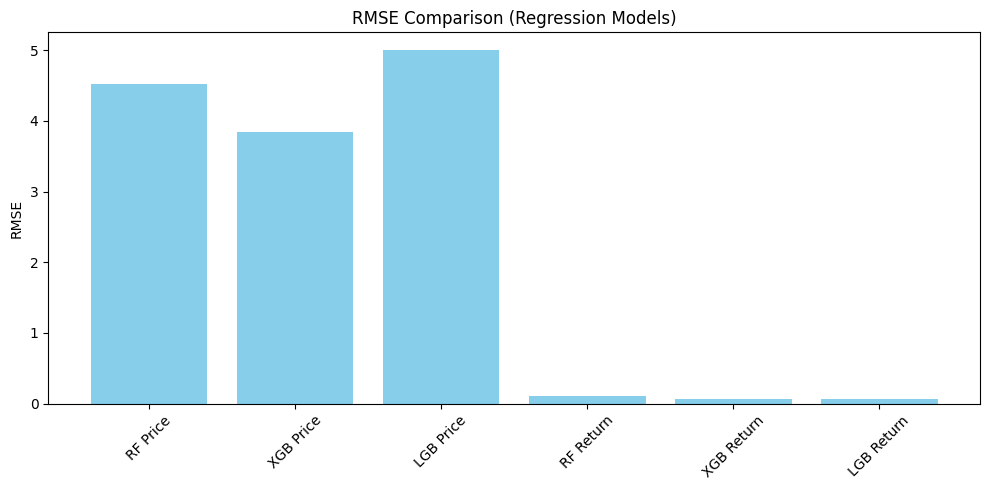

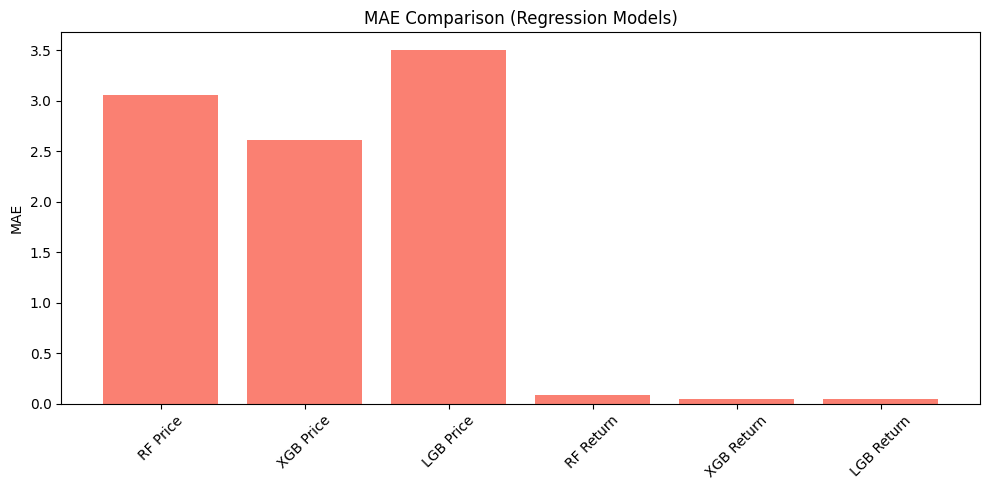

In [103]:
import matplotlib.pyplot as plt

# Regression metrics
reg_names = [
    "RF Price", "XGB Price", "LGB Price",
    "RF Return", "XGB Return", "LGB Return"
]

rmse_vals = regression_results["RMSE"].values
mae_vals = regression_results["MAE"].values

plt.figure(figsize=(10,5))
plt.bar(reg_names, rmse_vals, color='skyblue')
plt.xticks(rotation=45)
plt.title("RMSE Comparison (Regression Models)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("plots/rmse_comparison.png")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(reg_names, mae_vals, color='salmon')
plt.xticks(rotation=45)
plt.title("MAE Comparison (Regression Models)")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("plots/mae_comparison.png")
plt.show()



### 2. Classification Performance (Accuracy + F1)

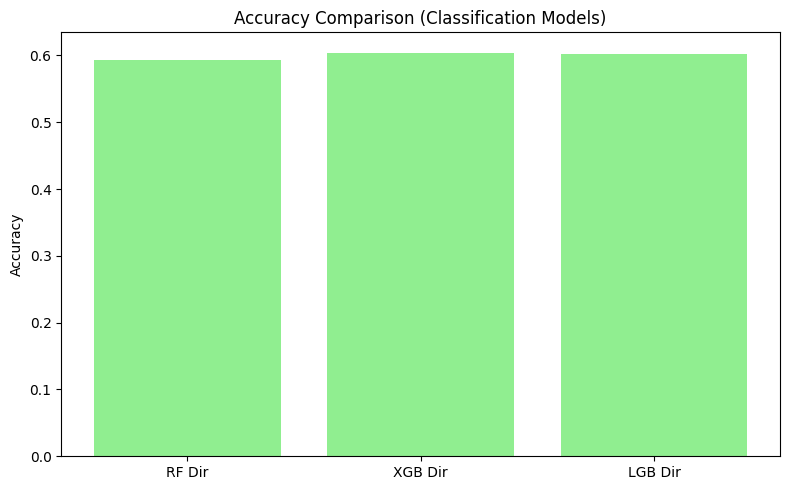

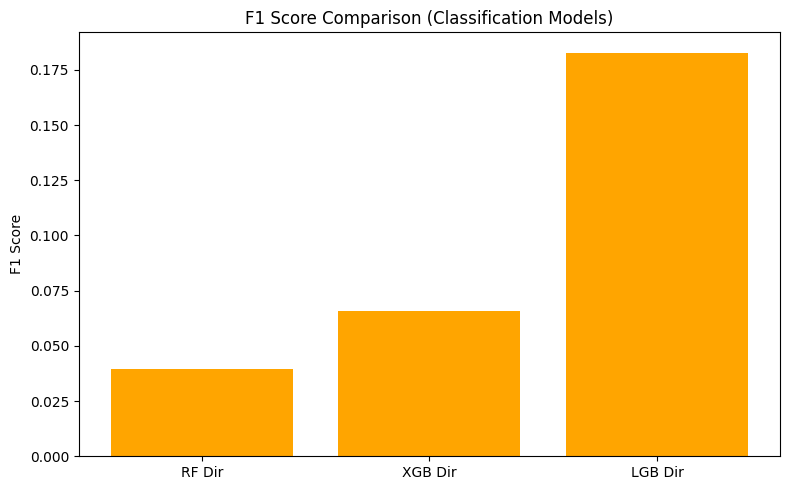

In [104]:
clf_names = ["RF Dir", "XGB Dir", "LGB Dir"]
acc_vals = classification_results["Accuracy"].values
f1_vals = classification_results["F1 Score"].values

plt.figure(figsize=(8,5))
plt.bar(clf_names, acc_vals, color='lightgreen')
plt.title("Accuracy Comparison (Classification Models)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("plots/accuracy_comparison.png")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(clf_names, f1_vals, color='orange')
plt.title("F1 Score Comparison (Classification Models)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.savefig("plots/f1_comparison.png")
plt.show()


### 3.Random Forest Feature Importance

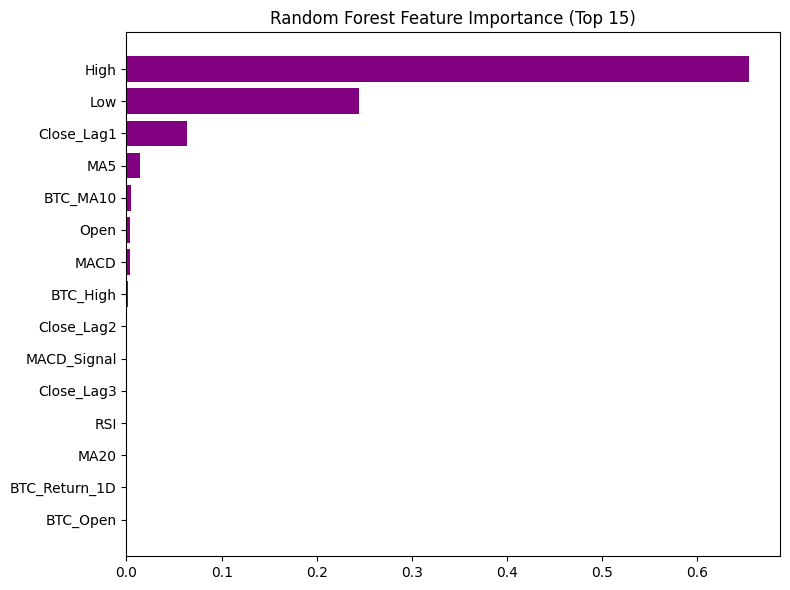

In [105]:
import numpy as np

importances = rf_price.feature_importances_
indices = np.argsort(importances)[-15:]  # top 15

plt.figure(figsize=(8,6))
plt.barh(X.columns[indices], importances[indices], color='purple')
plt.title("Random Forest Feature Importance (Top 15)")
plt.tight_layout()
plt.savefig("plots/rf_feature_importance.png")
plt.show()


### 4.Actual vs Predicted Price Chart

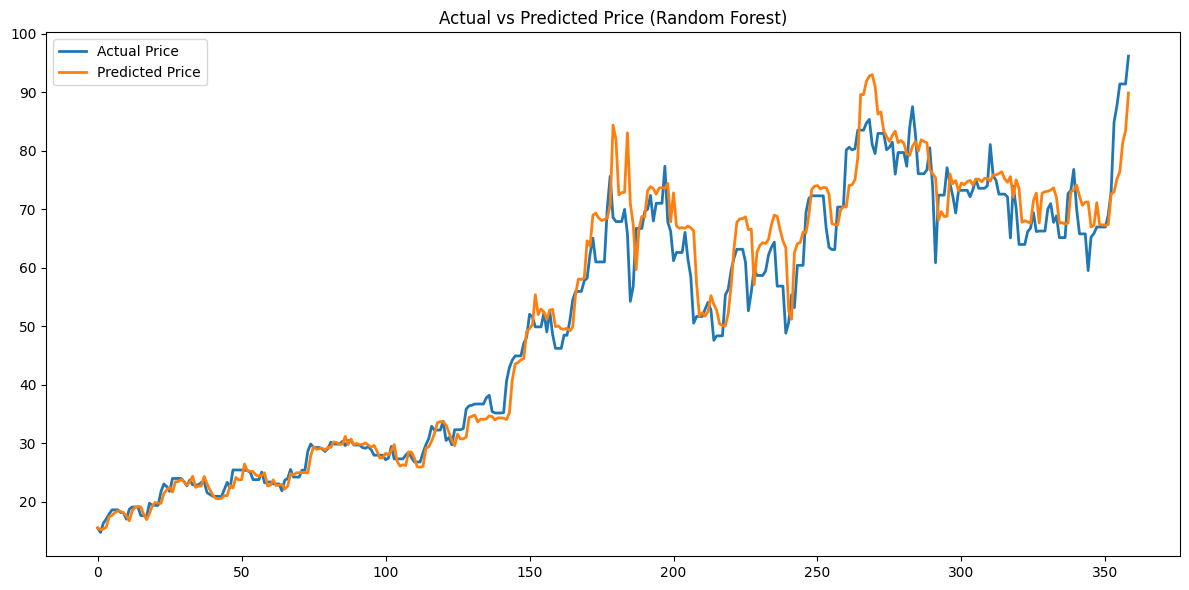

In [106]:
preds = rf_price.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(y_test_price.values, label="Actual Price", linewidth=2)
plt.plot(preds, label="Predicted Price", linewidth=2)
plt.title("Actual vs Predicted Price (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/actual_vs_predicted_price.png")
plt.show()


### 5.Direction Prediction Visualization

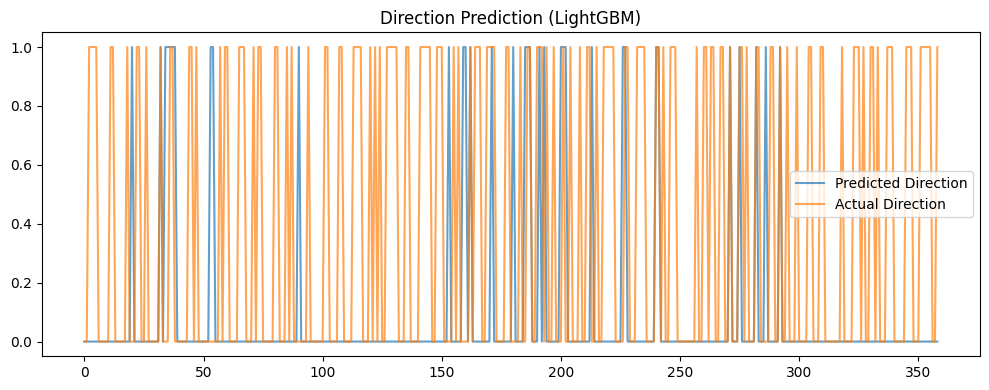

In [107]:
pred_dir = lgb_clf.predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(pred_dir, label="Predicted Direction", alpha=0.7)
plt.plot(y_test_dir.values, label="Actual Direction", alpha=0.7)
plt.title("Direction Prediction (LightGBM)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/direction_prediction.png")
plt.show()


### 6.Ensemble Confidence Visualization


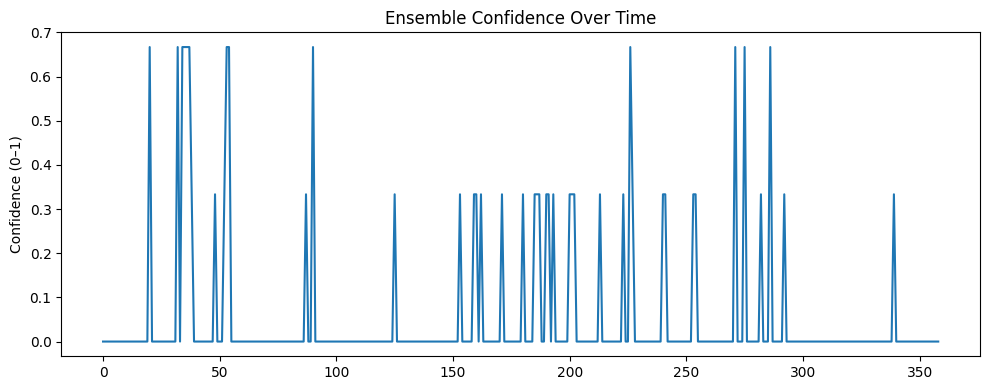

In [108]:
confidence_vals = []

for i in range(len(X_test)):
    votes = [
        rf_clf.predict(X_test.iloc[i:i+1])[0],
        xgb_clf.predict(X_test.iloc[i:i+1])[0],
        lgb_clf.predict(X_test.iloc[i:i+1])[0]
    ]
    confidence_vals.append(sum(votes)/3)

plt.figure(figsize=(10,4))
plt.plot(confidence_vals, label="Ensemble Confidence")
plt.title("Ensemble Confidence Over Time")
plt.ylabel("Confidence (0–1)")
plt.tight_layout()
plt.savefig("plots/ensemble_confidence.png")
plt.show()


In [109]:
# ============================================================
# FINAL OUTPUT — NEXT-DAY PREDICTION
# ============================================================

final_prediction = predict_next(df)

print("=== FINAL NEXT-DAY PREDICTIONS ===")

import yfinance as yf
import numpy as np
import pandas as pd

# Download FX data (5 days to avoid weekend issues)
fx_data = yf.download("CAD=X", period="5d")["Close"]

# Drop NaN rows
fx_data = fx_data.dropna()

# Extract last value safely (handles Series, arrays, nested arrays)
last_val = fx_data.tail(1)

# Convert to numpy array
last_val = np.array(last_val).flatten()

# Extract scalar
fx = float(last_val[0])

# Extract USD price as float
usd_price = float(final_prediction["Predicted Price"])

# Convert to CAD
cad_price = usd_price * fx

print(f"Predicted Price (USD): ${usd_price:.2f}")
print(f"Predicted Price (CAD): ${cad_price:.2f}")

print(f"Predicted Return: {float(final_prediction['Predicted Return (%)']):.2f}%")
print(f"Predicted Direction: {final_prediction['Predicted Direction']}")
print(f"Model Confidence: {float(final_prediction['Model Confidence (%)']):.2f}%")



[*********************100%***********************]  1 of 1 completed

=== FINAL NEXT-DAY PREDICTIONS ===
Predicted Price (USD): $89.65
Predicted Price (CAD): $123.61
Predicted Return: -0.73%
Predicted Direction: DOWN
Model Confidence: 0.00%


If Model Confidence Says 0 means all 3 models predicted that stock will go down.
If Model Confidence Says 1 means all 3 models predicted that stock will go up.